### 고장 핫스팟 모델링 (DBSCAN 중심 + KMeans 비교)
(1) 목적: 대여소 고장 핫스팟 군집 탐지 <br>
(2) 주 모델: DBSCAN <br>
(3) 비교 모델: KMeans <br>


### 1. 환경 설정


In [9]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
import sys
import subprocess
import warnings
import datetime
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Colab)
!apt-get -qq install fonts-nanum > /dev/null 2>&1
mpl.font_manager.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
mpl.rcParams['font.family'] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] = False

base_path = '/content/drive/MyDrive/26-1_BITAmin_TS_project'
PROCESSED_DIR = os.path.join(base_path, 'processed_data')
os.makedirs(PROCESSED_DIR, exist_ok=True)

print('base_path:', base_path)
print('processed_dir:', PROCESSED_DIR)


Mounted at /content/drive
base_path: /content/drive/MyDrive/26-1_BITAmin_TS_project
processed_dir: /content/drive/MyDrive/26-1_BITAmin_TS_project/processed_data


### 2. 라이브러리 설치


In [2]:
def ensure_package(pkg_name):
    try:
        __import__(pkg_name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg_name])

for pkg in ['scikit-learn', 'folium']:
    ensure_package(pkg)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score
import folium
from folium.plugins import MarkerCluster

print('패키지 설치 완료')


패키지 설치 완료


### 3. 데이터 로드


In [4]:
def pick_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

hotspot_path = pick_existing([
    os.path.join(PROCESSED_DIR, 'station_hotspot_map.parquet'),
])

assert hotspot_path is not None, '핫스팟 지도 파일이 없습니다. data_merged.ipynb를 먼저 실행하세요.'

hotspot_raw = pd.read_parquet(hotspot_path)
print('input file:', hotspot_path)
print('shape:', hotspot_raw.shape)
print('columns:', hotspot_raw.columns.tolist())
display(hotspot_raw.head())


input file: /content/drive/MyDrive/26-1_BITAmin_TS_project/processed_data/station_hotspot_map.parquet
shape: (5665, 8)
columns: ['추정고장대여소ID', '고장건수', '고장자전거수', '고장유형수', '첫고장일', '마지막고장일', '위도', '경도']


,추정고장대여소ID,고장건수,고장자전거수,고장유형수,첫고장일,마지막고장일,위도,경도
0,00583,1887,1552,6,2021-02-11 00:00:00,2025-12-28 18:05:02,37.567970,127.046890
1,04217,1546,1309,6,2022-07-01 18:28:00,2025-12-29 21:16:49,37.555576,126.896889
2,02102,1429,1137,6,2021-02-07 00:00:00,2025-12-28 15:22:50,37.484085,126.926888
3,02728,1400,1182,6,2021-04-11 00:00:00,2025-12-31 09:35:11,37.565804,126.828079
4,00502,1373,1146,6,2021-02-17 00:00:00,2025-12-22 08:35:13,37.531860,127.067192


### 4. 모델링 입력 전처리


In [10]:
need_cols = ['추정고장대여소ID', '위도', '경도', '고장건수']
missing = [c for c in need_cols if c not in hotspot_raw.columns]
assert len(missing) == 0, f'필수 컬럼 누락: {missing}'

work = hotspot_raw[need_cols].copy()
work['추정고장대여소ID'] = (
    work['추정고장대여소ID'].astype('string').str.strip()
    .str.replace(r'\.0$', '', regex=True)
    .str.replace(r'[^0-9]', '', regex=True)
    .replace({'': pd.NA})
    .str.zfill(5)
)
work['위도'] = pd.to_numeric(work['위도'], errors='coerce')
work['경도'] = pd.to_numeric(work['경도'], errors='coerce')
work['고장건수'] = pd.to_numeric(work['고장건수'], errors='coerce')

# 결측치, 이상치 제거
work = work.dropna(subset=['추정고장대여소ID', '위도', '경도', '고장건수']).copy()
work = work[work['고장건수'] > 0].copy()

# ID 정규화 이후 같은 대여소 버리지 않고 재집계
work = (
    work.groupby('추정고장대여소ID', as_index=False)
    .agg(
        위도=('위도', 'mean'),
        경도=('경도', 'mean'),
        고장건수=('고장건수', 'sum')
    )
)

# 모델 피처 (좌표 + 강도)
work['log_고장건수'] = np.log1p(work['고장건수'])
feature_cols = ['위도', '경도', 'log_고장건수']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(work[feature_cols])

print('modeling shape:', work.shape)
print('대여소 수:', len(work))
display(work.head())


modeling shape: (2790, 5)
대여소 수: 2790


,추정고장대여소ID,위도,경도,고장건수,log_고장건수
0,00102,37.555649,126.910629,754,6.626718
1,00103,37.554951,126.910835,623,6.436150
2,00104,37.550629,126.914986,274,5.616771
3,00105,37.550007,126.914825,125,4.836282
4,00106,37.548645,126.912826,458,6.129050


### 5. 기초 EDA


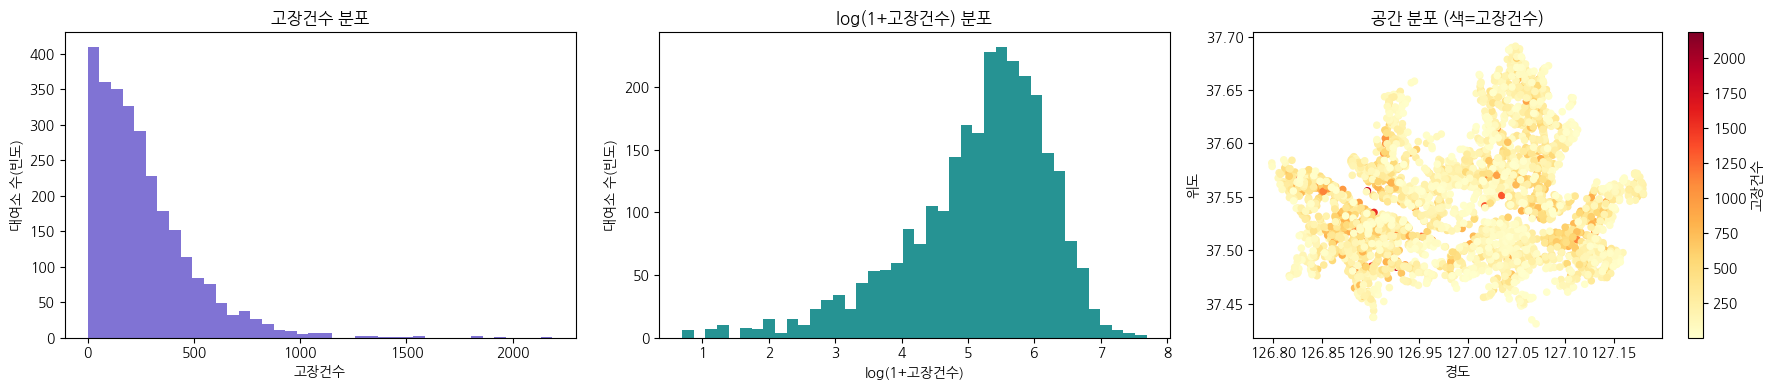

min 고장건수: 1
0건 개수: 0


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(work['고장건수'], bins=40, color='slateblue', alpha=0.85)
axes[0].set_title('고장건수 분포')
axes[0].set_xlabel('고장건수')
axes[0].set_ylabel('대여소 수(빈도)')

axes[1].hist(work['log_고장건수'], bins=40, color='teal', alpha=0.85)
axes[1].set_title('log(1+고장건수) 분포')
axes[1].set_xlabel('log(1+고장건수)')
axes[1].set_ylabel('대여소 수(빈도)')

sc = axes[2].scatter(work['경도'], work['위도'], c=work['고장건수'], cmap='YlOrRd', s=20)
axes[2].set_title('공간 분포 (색=고장건수)')
axes[2].set_xlabel('경도')
axes[2].set_ylabel('위도')
plt.colorbar(sc, ax=axes[2], label='고장건수')

plt.tight_layout()
plt.show()

print("min 고장건수:", work['고장건수'].min())
print("0건 개수:", (work['고장건수'] == 0).sum())


### 6. DBSCAN (주 모델)


In [16]:
# eps 후보 탐색
candidate_eps = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
min_samples = 6

scan_rows = []
for eps in candidate_eps:
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X_scaled)
    n_noise = int((labels == -1).sum())
    n_cluster = int(len(set(labels)) - (1 if -1 in labels else 0))
    non_noise = labels[labels != -1]
    sil = np.nan
    if n_cluster >= 2 and len(non_noise) >= 10:
        mask = labels != -1
        sil = float(silhouette_score(X_scaled[mask], labels[mask]))
    scan_rows.append({'eps': eps, 'clusters': n_cluster, 'noise': n_noise, 'silhouette_non_noise': sil})

scan_df = pd.DataFrame(scan_rows)
display(scan_df)

# 선택 규칙 설정: 군집 2개 이상이면서 silhouette 최대
valid = scan_df[scan_df['clusters'] >= 2].copy()
if len(valid) > 0 and valid['silhouette_non_noise'].notna().any():
    best_row = valid.sort_values('silhouette_non_noise', ascending=False).iloc[0]
else:
    best_row = scan_df.iloc[len(scan_df)//2]

best_eps = float(best_row['eps'])
print('선택된 eps:', best_eps)

dbscan = DBSCAN(eps=best_eps, min_samples=min_samples)
work['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

n_cluster = int(len(set(work['dbscan_cluster'])) - (1 if -1 in set(work['dbscan_cluster']) else 0))
noise_ratio = float((work['dbscan_cluster'] == -1).mean() * 100)
print('DBSCAN clusters:', n_cluster)
print('DBSCAN noise ratio(%):', round(noise_ratio, 2))


,eps,clusters,noise,silhouette_non_noise
0,0.30,14,337,-0.282652
1,0.35,9,215,-0.115142
2,0.40,3,136,0.136699
3,0.45,3,95,0.194818
4,0.50,3,81,0.214458
5,0.55,5,46,0.181125
6,0.60,5,27,0.212631
7,0.65,1,18,NaN
8,0.70,1,6,NaN


선택된 eps: 0.5
DBSCAN clusters: 3
DBSCAN noise ratio(%): 2.9


### 7. KMeans (비교 모델)


In [17]:
k_candidates = list(range(3, 9))
km_rows = []
for k in k_candidates:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    km_rows.append({'k': k, 'silhouette': float(sil), 'inertia': float(km.inertia_)})

km_df = pd.DataFrame(km_rows)
display(km_df)

best_k = int(km_df.sort_values('silhouette', ascending=False).iloc[0]['k'])
print('선택된 k:', best_k)

kmeans = KMeans(n_clusters=best_k, n_init=20, random_state=42)
work['kmeans_cluster'] = kmeans.fit_predict(X_scaled)


,k,silhouette,inertia
0,3,0.310854,4511.723178
1,4,0.340139,3341.090314
2,5,0.293737,2978.176125
3,6,0.291546,2662.851814
4,7,0.282558,2394.789282
5,8,0.281635,2167.187391


선택된 k: 4


### 8. 결과 비교 EDA


[DBSCAN 요약]


,dbscan_cluster,대여소수,평균고장건수,총고장건수
1,0,2694,270.419822,728511
0,-1,81,96.049383,7780
2,1,9,18.333333,165
3,2,6,14.500000,87


[KMeans 요약]


,kmeans_cluster,대여소수,평균고장건수,총고장건수
3,3,943,366.447508,345560
1,1,674,297.964392,200828
2,2,744,235.864247,175483
0,0,429,34.200466,14672


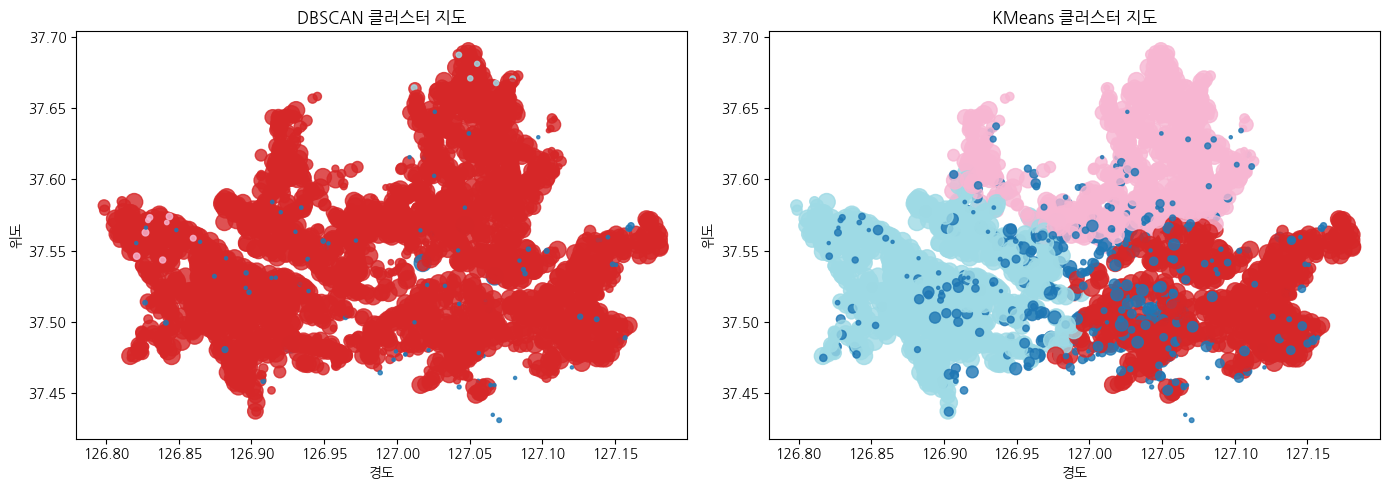

In [18]:
summary_db = (
    work.groupby('dbscan_cluster', as_index=False)
    .agg(
        대여소수=('추정고장대여소ID', 'count'),
        평균고장건수=('고장건수', 'mean'),
        총고장건수=('고장건수', 'sum')
    )
    .sort_values('총고장건수', ascending=False)
)

summary_km = (
    work.groupby('kmeans_cluster', as_index=False)
    .agg(
        대여소수=('추정고장대여소ID', 'count'),
        평균고장건수=('고장건수', 'mean'),
        총고장건수=('고장건수', 'sum')
    )
    .sort_values('총고장건수', ascending=False)
)

print('[DBSCAN 요약]')
display(summary_db)
print('[KMeans 요약]')
display(summary_km)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    work['경도'], work['위도'],
    c=work['dbscan_cluster'], cmap='tab20', s=np.clip(work['고장건수'], 5, 150), alpha=0.8
)
axes[0].set_title('DBSCAN 클러스터 지도')
axes[0].set_xlabel('경도')
axes[0].set_ylabel('위도')

axes[1].scatter(
    work['경도'], work['위도'],
    c=work['kmeans_cluster'], cmap='tab20', s=np.clip(work['고장건수'], 5, 150), alpha=0.8
)
axes[1].set_title('KMeans 클러스터 지도')
axes[1].set_xlabel('경도')
axes[1].set_ylabel('위도')

plt.tight_layout()
plt.show()


### 9. 저장 (Streamlit 연동용)


In [19]:
clustered_hotspot = work.copy()

# UI 기본 군집 KMeans 사용
clustered_hotspot['ui_cluster'] = clustered_hotspot['kmeans_cluster']

# 핫스팟 강조용 등급(상위 10%, 30%)
q90 = clustered_hotspot['고장건수'].quantile(0.90)
q70 = clustered_hotspot['고장건수'].quantile(0.70)

clustered_hotspot['핫스팟등급'] = 'LOW'
clustered_hotspot.loc[clustered_hotspot['고장건수'] >= q70, '핫스팟등급'] = 'MID'
clustered_hotspot.loc[clustered_hotspot['고장건수'] >= q90, '핫스팟등급'] = 'HIGH'

clustered_cols = [
    '추정고장대여소ID', '위도', '경도', '고장건수', 'log_고장건수',
    'dbscan_cluster', 'kmeans_cluster', 'ui_cluster', '핫스팟등급'
]
clustered_hotspot = clustered_hotspot[clustered_cols].copy()

clustered_parquet_path = os.path.join(PROCESSED_DIR, 'clustered_hotspot.parquet')
clustered_csv_path = os.path.join(PROCESSED_DIR, 'clustered_hotspot.csv')
clustered_hotspot.to_parquet(clustered_parquet_path, index=False)
clustered_hotspot.to_csv(clustered_csv_path, index=False, encoding='utf-8-sig')

# 모델 번들 저장
model_bundle = {
    'created_at': datetime.datetime.now().isoformat(),
    'input_file': hotspot_path,
    'feature_cols': feature_cols,
    'scaler': scaler,
    'dbscan_model': dbscan,
    'dbscan_eps': best_eps,
    'dbscan_min_samples': min_samples,
    'kmeans_model': kmeans,
    'kmeans_k': best_k,
    'ui_default_model': 'kmeans',
}

model_path = os.path.join(PROCESSED_DIR, 'model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(model_bundle, f)

# 파일 저장
summary_db_out = summary_db.rename(columns={'dbscan_cluster': 'cluster_id'}).copy()
summary_db_out['model'] = 'DBSCAN'

summary_km_out = summary_km.rename(columns={'kmeans_cluster': 'cluster_id'}).copy()
summary_km_out['model'] = 'KMeans'

summary_all = pd.concat([summary_db_out, summary_km_out], ignore_index=True)
summary_path = os.path.join(PROCESSED_DIR, 'cluster_summary.parquet')
summary_all.to_parquet(summary_path, index=False)

print('저장 완료:')
print('-', clustered_parquet_path)
print('-', clustered_csv_path)
print('-', model_path)
print('-', summary_path)

저장 완료:
- /content/drive/MyDrive/26-1_BITAmin_TS_project/processed_data/clustered_hotspot.parquet
- /content/drive/MyDrive/26-1_BITAmin_TS_project/processed_data/clustered_hotspot.csv
- /content/drive/MyDrive/26-1_BITAmin_TS_project/processed_data/model.pkl
- /content/drive/MyDrive/26-1_BITAmin_TS_project/processed_data/cluster_summary.parquet


### 10. Folium 미리보기 지도


In [21]:
center_lat = float(clustered_hotspot['위도'].mean())
center_lon = float(clustered_hotspot['경도'].mean())

m = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles='CartoDB positron')
mc = MarkerCluster().add_to(m)

for _, row in clustered_hotspot.iterrows():
    popup = (
        f"ID: {row['추정고장대여소ID']}<br>"
        f"고장건수: {int(row['고장건수'])}<br>"
        f"DBSCAN: {int(row['dbscan_cluster'])}<br>"
        f"KMeans: {int(row['kmeans_cluster'])}"
    )
    folium.CircleMarker(
        location=[row['위도'], row['경도']],
        radius=max(3, min(12, row['고장건수'] / 50)),
        popup=popup,
        color='#d35400',
        fill=True,
        fill_opacity=0.65,
    ).add_to(mc)

map_path = os.path.join(PROCESSED_DIR, 'hotspot_map_preview.html')
m.save(map_path)
m


Output hidden; open in https://colab.research.google.com to view.